# FIAP TECH CHALLENGE 1 - GRUPO SSP

## 4. MODELO PREDITIVO - REGRESSÃO LOGÍSTICA

Escolhemos a regressão logística como nossa técnica baseline devido a sua relativa simplicidade.

In [33]:
from pathlib import aPath

# Considerando que o Notebook está sendo rodado em /src/notebooks/
BASE_PATH = Path.cwd().resolve().parent.parent
print(f"📁 Base path: {BASE_PATH.absolute()}")

📁 Base path: /Users/matias/Projetos/fiap/tech-challenge-1


In [34]:
import pandas as pd
import numpy as np

# top_10_features = ['REL_CONHECIDO', 'REL_PARCEIRO_INTIMO', 'AG_AMEACA', 'VIOL_PSICO', 'AUTOR_SEXO', 'SIT_CONJUG', 'VIOL_FINAN', 'REL_INSTITUCIONAL', 'AG_ENFOR', 'CICL_VID']


# Carregar dados pré-processados
df = pd.read_parquet(BASE_PATH / "data" / "processed" / "df_preprocessed.parquet")

# Filtrar as 10 features mais relevantes e a target
# df = df[top_10_features + ['OUT_VEZES']]

print(f"📊 Shape do dataset: {df.shape}")
print(f"\n📋 Colunas: {df.columns.tolist()}")

📊 Shape do dataset: (57022, 38)

📋 Colunas: ['AG_AMEACA', 'AG_CORTE', 'AG_ENFOR', 'AG_ENVEN', 'AG_FOGO', 'AG_FORCA', 'AG_OBJETO', 'AG_OUTROS', 'AG_QUENTE', 'AUTOR_ALCO', 'AUTOR_SEXO', 'CICL_VID', 'CS_RACA', 'DEF_TRANS', 'IDENT_GEN', 'ORIENT_SEX', 'OUT_VEZES', 'SG_UF', 'SIT_CONJUG', 'VIOL_FINAN', 'VIOL_FISIC', 'VIOL_INFAN', 'VIOL_LEGAL', 'VIOL_NEGLI', 'VIOL_OUTR', 'VIOL_PSICO', 'VIOL_SEXU', 'VIOL_TORT', 'VIOL_TRAF', 'DIA_SEMANA_OCOR', 'MES_OCOR', 'REL_PARCEIRO_INTIMO', 'REL_FAMILIAR', 'REL_CONHECIDO', 'REL_INSTITUCIONAL', 'REL_OUTROS_FLAG', 'ESCOLARIDADE', 'CIRC_LESAO_FAMILIA']


📊 Distribuição da variável target (OUT_VEZES):
OUT_VEZES
1.0    30277
0.0    26745
Name: count, dtype: int64

📈 Proporção:
OUT_VEZES
1.0    0.530971
0.0    0.469029
Name: proportion, dtype: float64


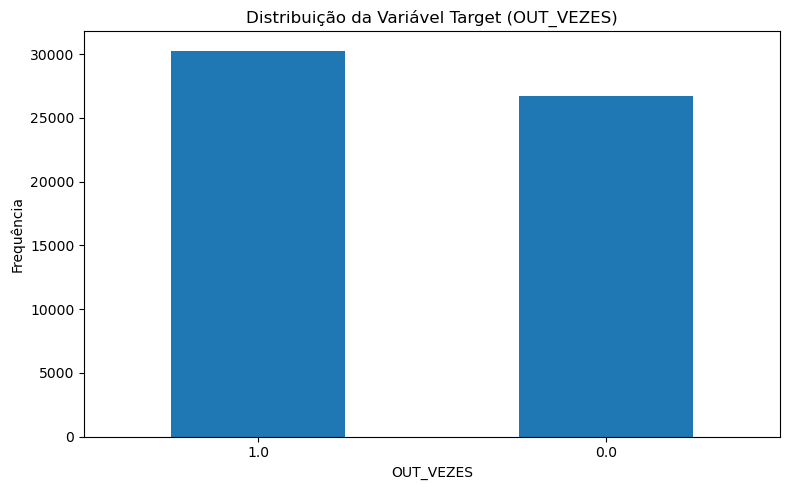

In [35]:
# Análise da variável target OUT_VEZES
print("📊 Distribuição da variável target (OUT_VEZES):")
print(df['OUT_VEZES'].value_counts())
print(f"\n📈 Proporção:")
print(df['OUT_VEZES'].value_counts(normalize=True))

# Visualização
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8, 5))
df['OUT_VEZES'].value_counts().plot(kind='bar')
plt.title('Distribuição da Variável Target (OUT_VEZES)')
plt.xlabel('OUT_VEZES')
plt.ylabel('Frequência')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

In [36]:
from sklearn.preprocessing import LabelEncoder

# Separar features e target
# Remover linhas com NaN na target
df_clean = df.dropna(subset=['OUT_VEZES']).copy()

# Separar features (X) e target (y)
# IMPORTANTE: Remover a coluna target das features!
X = df_clean.drop(columns=['OUT_VEZES']).copy()
y = df_clean['OUT_VEZES'].copy()

print(f"📊 Features (X): {X.shape}")
print(f"📊 Target (y): {y.shape}")
print(f"\n📋 Colunas de features: {X.columns.tolist()}")

# Como TODAS as colunas são categóricas, vamos aplicar LabelEncoder em todas
label_encoders = {}  # Dicionário para guardar os encoders (útil para decodificar depois)
X_encoded = X.copy()

# Encoding de todas as features categóricas
print("\n🔄 Aplicando LabelEncoder em todas as features categóricas...")
for col in X.columns:
    # Converter para string para lidar com valores mistos e NaN
    col_data = X_encoded[col].astype(str)
    
    # Tratar 'nan' (string) antes do encoding - substituir pela moda
    if col_data.str.contains('nan', case=False, na=False).any():
        mode_value = col_data[col_data != 'nan'].mode()[0] if len(col_data[col_data != 'nan'].mode()) > 0 else '0'
        col_data = col_data.replace('nan', mode_value)
    
    # Criar e aplicar LabelEncoder
    le = LabelEncoder()
    X_encoded[col] = le.fit_transform(col_data)
    label_encoders[col] = le  # Guardar o encoder para uso futuro
    
    print(f"  ✅ {col}: {len(le.classes_)} categorias únicas")

# Verificar se ainda há valores faltantes (não deveria ter após o LabelEncoder)
print("\n🔧 Verificando valores faltantes...")
missing_count = X_encoded.isna().sum().sum()
if missing_count > 0:
    print(f"  ⚠️ Encontrados {missing_count} valores faltantes")
    # Preencher com a moda de cada coluna usando atribuição direta (evita warning)
    for col in X_encoded.columns:
        mode_value = X_encoded[col].mode()[0] if len(X_encoded[col].mode()) > 0 else 0
        X_encoded[col] = X_encoded[col].fillna(mode_value)  # Sem inplace=True
    print("  ✅ Valores faltantes tratados")
else:
    print("  ✅ Nenhum valor faltante encontrado")

# Encoding da target (se necessário)
print("\n🎯 Encoding da variável target...")
if y.dtype == 'object':
    le_target = LabelEncoder()
    y_encoded = le_target.fit_transform(y.astype(str))
    print(f"  Classes originais: {le_target.classes_}")
    print(f"  Classes codificadas: {np.unique(y_encoded)}")
    y = y_encoded
else:
    print(f"  Target já é numérica: {np.unique(y)}")

print(f"\n✅ Dataset preparado:")
print(f"  Features (X_encoded): {X_encoded.shape}")
print(f"  Target (y): {y.shape}")
print(f"  Tipo de dados: {X_encoded.dtypes.unique()}")

📊 Features (X): (57022, 37)
📊 Target (y): (57022,)

📋 Colunas de features: ['AG_AMEACA', 'AG_CORTE', 'AG_ENFOR', 'AG_ENVEN', 'AG_FOGO', 'AG_FORCA', 'AG_OBJETO', 'AG_OUTROS', 'AG_QUENTE', 'AUTOR_ALCO', 'AUTOR_SEXO', 'CICL_VID', 'CS_RACA', 'DEF_TRANS', 'IDENT_GEN', 'ORIENT_SEX', 'SG_UF', 'SIT_CONJUG', 'VIOL_FINAN', 'VIOL_FISIC', 'VIOL_INFAN', 'VIOL_LEGAL', 'VIOL_NEGLI', 'VIOL_OUTR', 'VIOL_PSICO', 'VIOL_SEXU', 'VIOL_TORT', 'VIOL_TRAF', 'DIA_SEMANA_OCOR', 'MES_OCOR', 'REL_PARCEIRO_INTIMO', 'REL_FAMILIAR', 'REL_CONHECIDO', 'REL_INSTITUCIONAL', 'REL_OUTROS_FLAG', 'ESCOLARIDADE', 'CIRC_LESAO_FAMILIA']

🔄 Aplicando LabelEncoder em todas as features categóricas...
  ✅ AG_AMEACA: 2 categorias únicas
  ✅ AG_CORTE: 2 categorias únicas
  ✅ AG_ENFOR: 2 categorias únicas
  ✅ AG_ENVEN: 2 categorias únicas
  ✅ AG_FOGO: 2 categorias únicas
  ✅ AG_FORCA: 2 categorias únicas
  ✅ AG_OBJETO: 2 categorias únicas
  ✅ AG_OUTROS: 2 categorias únicas
  ✅ AG_QUENTE: 2 categorias únicas
  ✅ AUTOR_ALCO: 2 categoria

DIVISÃO DOS DADOS:
  Treino: 39915 amostras (70.0%)
  Teste: 17107 amostras (30.0%)

Distribuição da target no conjunto de TREINO:
  Classe 0.0: 0.4690 (46.90%)
  Classe 1.0: 0.5310 (53.10%)

Distribuição da target no conjunto de TESTE:
  Classe 0.0: 0.4690 (46.90%)
  Classe 1.0: 0.5310 (53.10%)


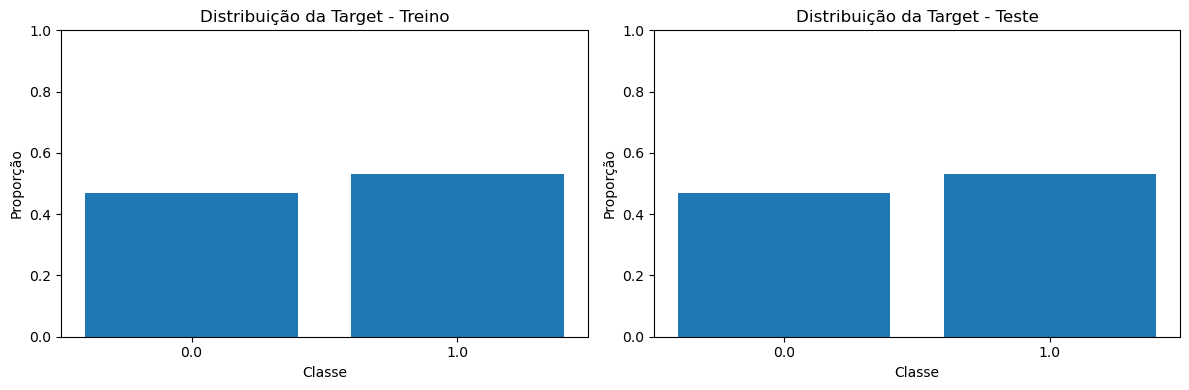

In [37]:
from sklearn.model_selection import train_test_split

# Divisão treino/teste (70% treino, 30% teste)
# stratify=y garante que a proporção de classes seja mantida em ambos os conjuntos
X_train, X_test, y_train, y_test = train_test_split(
    X_encoded, y, 
    test_size=0.3, 
    random_state=42, 
    stratify=y  # Mantém a proporção de classes
)

print("DIVISÃO DOS DADOS:")
print(f"  Treino: {X_train.shape[0]} amostras ({X_train.shape[0]/len(X_encoded)*100:.1f}%)")
print(f"  Teste: {X_test.shape[0]} amostras ({X_test.shape[0]/len(X_encoded)*100:.1f}%)")
print(f"\nDistribuição da target no conjunto de TREINO:")
train_dist = pd.Series(y_train).value_counts(normalize=True).sort_index()
for classe, prop in train_dist.items():
    print(f"  Classe {classe}: {prop:.4f} ({prop*100:.2f}%)")

print(f"\nDistribuição da target no conjunto de TESTE:")
test_dist = pd.Series(y_test).value_counts(normalize=True).sort_index()
for classe, prop in test_dist.items():
    print(f"  Classe {classe}: {prop:.4f} ({prop*100:.2f}%)")

# Visualização da distribuição
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Treino
axes[0].bar(train_dist.index.astype(str), train_dist.values)
axes[0].set_title('Distribuição da Target - Treino')
axes[0].set_xlabel('Classe')
axes[0].set_ylabel('Proporção')
axes[0].set_ylim([0, 1])

# Teste
axes[1].bar(test_dist.index.astype(str), test_dist.values)
axes[1].set_title('Distribuição da Target - Teste')
axes[1].set_xlabel('Classe')
axes[1].set_ylabel('Proporção')
axes[1].set_ylim([0, 1])

plt.tight_layout()
plt.show()

In [38]:
# Verificar possíveis problemas nos dados
print("🔍 Verificando qualidade dos dados...")

# 1. Verificar se há valores infinitos
print(f"  Valores infinitos em X_train: {np.isinf(X_train.values).sum()}")
print(f"  Valores infinitos em X_test: {np.isinf(X_test.values).sum()}")

# 2. Verificar variância (features com variância zero não ajudam)
variances = X_train.var()
zero_var_cols = variances[variances == 0].index.tolist()
if zero_var_cols:
    print(f"  ⚠️ Colunas com variância zero: {zero_var_cols}")
    # Remover essas colunas
    X_train = X_train.drop(columns=zero_var_cols)
    X_test = X_test.drop(columns=zero_var_cols)
    print(f"  ✅ Colunas removidas. Novo shape: {X_train.shape}")

# 3. Verificar correlação muito alta (multicolinearidade)
corr_matrix = X_train.corr().abs()
high_corr_pairs = []
for i in range(len(corr_matrix.columns)):
    for j in range(i+1, len(corr_matrix.columns)):
        if corr_matrix.iloc[i, j] > 0.95:  # Correlação > 95%
            high_corr_pairs.append((corr_matrix.columns[i], corr_matrix.columns[j]))
if high_corr_pairs:
    print(f"  ⚠️ Encontradas {len(high_corr_pairs)} pares com correlação > 95%")
    print(f"  Primeiros 5: {high_corr_pairs[:5]}")

🔍 Verificando qualidade dos dados...
  Valores infinitos em X_train: 0
  Valores infinitos em X_test: 0


In [39]:
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler

# NORMALIZAR OS DADOS (CRÍTICO para regressão logística!)
print("📊 Normalizando os dados...")
scaler = StandardScaler()

# Aplicar normalização apenas nas features (não na target)
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Converter de volta para DataFrame para manter nomes das colunas
X_train_scaled = pd.DataFrame(X_train_scaled, columns=X_train.columns, index=X_train.index)
X_test_scaled = pd.DataFrame(X_test_scaled, columns=X_test.columns, index=X_test.index)

print("Dados normalizados!")
print(f"  Média das features (treino): {X_train_scaled.mean(axis=0).abs().max():.6f}")  # Deve estar próximo de 0
print(f"  Desvio padrão (treino): {X_train_scaled.std(axis=0).min():.6f}")  # Deve estar próximo de 1

# Criar e treinar o modelo de Regressão Logística
print("\n🚀 Treinando modelo de Regressão Logística...")
print("=" * 60)

# Usar solver 'saga' que é mais robusto e aceita regularização L1 ou L2
model = LogisticRegression(
    max_iter=10000,
    random_state=42,
    class_weight='balanced',
    solver='saga',
    C=10.0,               
    penalty='l2',
    tol=1e-4,
    n_jobs=-1
)

# Treinar o modelo com dados NORMALIZADOS
model.fit(X_train_scaled, y_train)

print("✅ Modelo treinado com sucesso!")
print(f"\n📊 Informações do modelo:")
print(f"  Número de iterações realizadas: {model.n_iter_[0]}")
print(f"  Número de features: {model.n_features_in_}")
print(f"  Número de classes: {len(model.classes_)}")
print(f"  Classes: {model.classes_}")

📊 Normalizando os dados...
Dados normalizados!
  Média das features (treino): 0.000000
  Desvio padrão (treino): 1.000013

🚀 Treinando modelo de Regressão Logística...
✅ Modelo treinado com sucesso!

📊 Informações do modelo:
  Número de iterações realizadas: 27
  Número de features: 37
  Número de classes: 2
  Classes: [0. 1.]


Fazendo predições...
Predições concluídas!

MÉTRICAS DO MODELO

Métricas Gerais:
  Acurácia:  0.7006 (70.06%)
  Precisão:  0.7003 (70.03%)
  Recall:    0.7006 (70.06%)
  F1-Score:  0.6995 (69.95%)
  ROC-AUC:   0.7600 (76.00%)

Métricas por Classe:
              precision    recall  f1-score   support

    Classe 0       0.70      0.64      0.67      8024
    Classe 1       0.70      0.75      0.73      9083

    accuracy                           0.70     17107
   macro avg       0.70      0.70      0.70     17107
weighted avg       0.70      0.70      0.70     17107


MATRIZ DE CONFUSÃO

                Pred: Classe 0  Pred: Classe 1
Real: Classe 0            5154            2870
Real: Classe 1            2252            6831

  Verdadeiros Negativos (TN): 5154
  Falsos Positivos (FP):      2870
  Falsos Negativos (FN):      2252
  Verdadeiros Positivos (TP): 6831


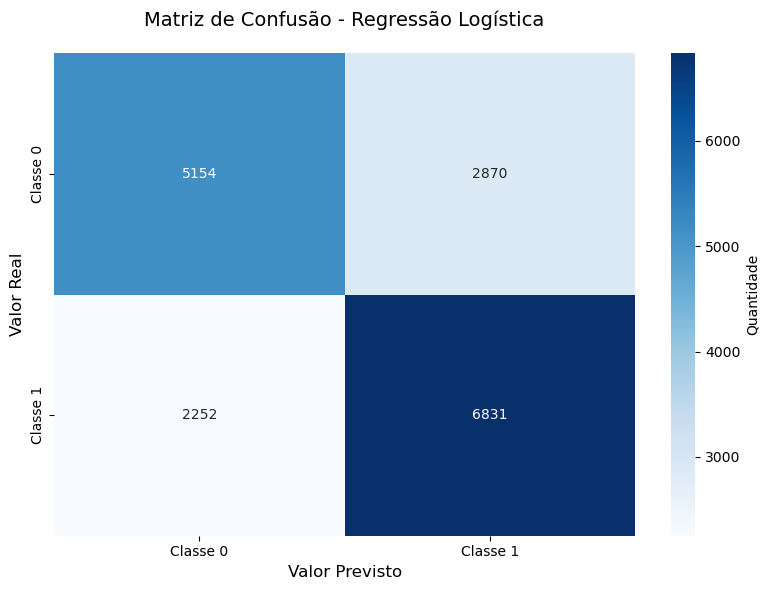

In [40]:
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, classification_report, roc_auc_score, roc_curve
)

# Predições
print("Fazendo predições...")
y_pred = model.predict(X_test_scaled)
y_pred_proba = model.predict_proba(X_test_scaled)[:, 1]  # Probabilidades da classe positiva

print("Predições concluídas!\n")

# Métricas principais
print("=" * 60)
print("MÉTRICAS DO MODELO")
print("=" * 60)

accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred, average='weighted', zero_division=0)
recall = recall_score(y_test, y_pred, average='weighted', zero_division=0)
f1 = f1_score(y_test, y_pred, average='weighted', zero_division=0)

print(f"\nMétricas Gerais:")
print(f"  Acurácia:  {accuracy:.4f} ({accuracy*100:.2f}%)")
print(f"  Precisão:  {precision:.4f} ({precision*100:.2f}%)")
print(f"  Recall:    {recall:.4f} ({recall*100:.2f}%)")
print(f"  F1-Score:  {f1:.4f} ({f1*100:.2f}%)")

# ROC-AUC (apenas para classificação binária)
if len(np.unique(y_test)) == 2:
    try:
        roc_auc = roc_auc_score(y_test, y_pred_proba)
        print(f"  ROC-AUC:   {roc_auc:.4f} ({roc_auc*100:.2f}%)")
    except Exception as e:
        print(f"  ROC-AUC:   Não foi possível calcular ({e})")

# Métricas por classe
print(f"\nMétricas por Classe:")
print(classification_report(y_test, y_pred, target_names=['Classe 0', 'Classe 1']))

# Matriz de confusão
print("\n" + "=" * 60)
print("MATRIZ DE CONFUSÃO")
print("=" * 60)
cm = confusion_matrix(y_test, y_pred)

# Criar DataFrame para melhor visualização
cm_df = pd.DataFrame(
    cm,
    index=['Real: Classe 0', 'Real: Classe 1'],
    columns=['Pred: Classe 0', 'Pred: Classe 1']
)

print("\n" + cm_df.to_string())
print(f"\n  Verdadeiros Negativos (TN): {cm[0, 0]}")
print(f"  Falsos Positivos (FP):      {cm[0, 1]}")
print(f"  Falsos Negativos (FN):      {cm[1, 0]}")
print(f"  Verdadeiros Positivos (TP): {cm[1, 1]}")

# Visualização da matriz de confusão
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['Classe 0', 'Classe 1'],
            yticklabels=['Classe 0', 'Classe 1'],
            cbar_kws={'label': 'Quantidade'})
plt.title('Matriz de Confusão - Regressão Logística', fontsize=14, pad=20)
plt.ylabel('Valor Real', fontsize=12)
plt.xlabel('Valor Previsto', fontsize=12)
plt.tight_layout()
plt.show()